## DATA VISUALIZATION

Berisi 5 KPI, Grafik Utama, Tabel Model, Daftar Mahasiswa Beresiko

**LOAD DATA**

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Tugas Big-Data/OULAD_EarlyWarning/"
processed_path = os.path.join(base_path, "data/processed/")
output_path = os.path.join(base_path, "data/output/")

# load data utama
merged_data = pd.read_csv(processed_path + "merged_processed_oulad.csv")

print("Ukuran merged_data:", merged_data.shape)
display(merged_data.head())

# optional: load output analysis jika sudah ada
model_comparison = None
feature_importance_dt = None
prediction_result = None
at_risk_students = None

if os.path.exists(output_path + "model_comparison.csv"):
    model_comparison = pd.read_csv(output_path + "model_comparison.csv")

if os.path.exists(output_path + "feature_importance_dt.csv"):
    feature_importance_dt = pd.read_csv(output_path + "feature_importance_dt.csv")

if os.path.exists(output_path + "prediction_result.csv"):
    prediction_result = pd.read_csv(output_path + "prediction_result.csv")

if os.path.exists(output_path + "at_risk_students.csv"):
    at_risk_students = pd.read_csv(output_path + "at_risk_students.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ukuran merged_data: (32593, 28)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,active_days,avg_score,max_score,total_assessments,total_submitted,assessment_completion_rate,module_presentation_length,risk_label,low_engagement,low_score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,40.0,82.0,85.0,5.0,5.0,1.0,268,0,0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,80.0,66.4,70.0,5.0,5.0,1.0,268,0,0,1
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,12.0,0.0,0.0,0.0,0.0,0.0,268,1,1,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,123.0,76.0,88.0,5.0,5.0,1.0,268,0,0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,70.0,54.4,75.0,5.0,5.0,1.0,268,0,0,1


**KPI UTAMA**

In [3]:
total_students = len(merged_data)

withdrawal_rate = (merged_data["final_result"].isin(["Withdrawn", "Withdrawal"]).mean()) * 100
fail_rate = (merged_data["final_result"].eq("Fail").mean()) * 100

# engagement rate: mahasiswa yang tidak low_engagement
if "low_engagement" in merged_data.columns:
    engagement_rate = (merged_data["low_engagement"].eq(0).mean()) * 100
else:
    engagement_rate = None

# assessment completion rate rata-rata
if "assessment_completion_rate" in merged_data.columns:
    avg_assessment_completion = merged_data["assessment_completion_rate"].mean() * 100
else:
    avg_assessment_completion = None

# early risk detection rate (proxy sederhana dari risk_label)
if "risk_label" in merged_data.columns:
    at_risk_rate = (merged_data["risk_label"].eq(1).mean()) * 100
else:
    at_risk_rate = None

kpi_df = pd.DataFrame({
    "KPI": [
        "Total Students",
        "Withdrawal Rate (%)",
        "Fail Rate (%)",
        "Student Engagement Rate (%)",
        "Assessment Completion Rate (%)",
        "At-Risk Student Rate (%)"
    ],
    "Value": [
        total_students,
        round(withdrawal_rate, 2),
        round(fail_rate, 2),
        round(engagement_rate, 2) if engagement_rate is not None else None,
        round(avg_assessment_completion, 2) if avg_assessment_completion is not None else None,
        round(at_risk_rate, 2) if at_risk_rate is not None else None
    ]
})

display(kpi_df)

,KPI,Value
0,Total Students,32593.00
1,Withdrawal Rate (%),31.16
2,Fail Rate (%),21.64
3,Student Engagement Rate (%),50.03
4,Assessment Completion Rate (%),78.00
5,At-Risk Student Rate (%),52.80


**Interpretasi hasil KPI:**

Tabel KPI ini menjadi ringkasan dashboard. Fokus utamanya adalah melihat seberapa besar tingkat withdrawal, fail, engagement, dan risiko mahasiswa secara umum.

**DISTRIBUSI HASIL AKHIR MAHASISWA**

,final_result,jumlah_mahasiswa
0,Pass,12361
1,Withdrawn,10156
2,Fail,7052
3,Distinction,3024


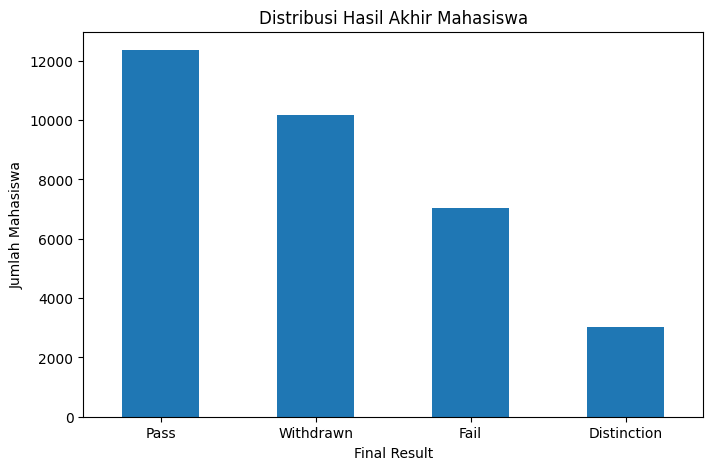

In [4]:
final_result_count = merged_data["final_result"].value_counts().reset_index()
final_result_count.columns = ["final_result", "jumlah_mahasiswa"]
display(final_result_count)

plt.figure(figsize=(8,5))
merged_data["final_result"].value_counts().plot(kind="bar")
plt.title("Distribusi Hasil Akhir Mahasiswa")
plt.xlabel("Final Result")
plt.ylabel("Jumlah Mahasiswa")
plt.xticks(rotation=0)
plt.show()

**PERSENTASE FINAL RESULT PER MODUL**

final_result,Distinction,Fail,Pass,Withdrawn
code_module,,,,
AAA,5.88,12.17,65.11,16.84
BBB,8.56,22.34,38.91,30.19
CCC,11.23,17.61,26.61,44.54
DDD,6.11,22.51,35.51,35.87
EEE,12.13,19.15,44.10,24.61
FFF,8.63,22.04,38.37,30.96
GGG,15.63,28.73,44.12,11.52


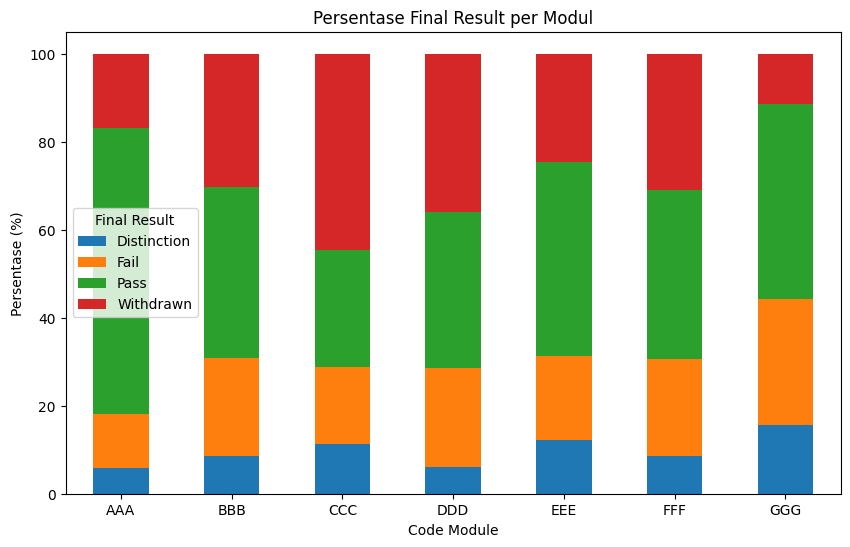

In [5]:
module_result_pct = pd.crosstab(
    merged_data["code_module"],
    merged_data["final_result"],
    normalize="index"
) * 100

display(module_result_pct.round(2))

module_result_pct.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Persentase Final Result per Modul")
plt.xlabel("Code Module")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(title="Final Result")
plt.show()

**AKTIVITAS VLE BERDASARKAN FINAL RESULT**

,total_clicks,avg_clicks,active_days,last_interaction_day
final_result,,,,
Distinction,2666.76,3.61,110.04,244.79
Fail,651.85,2.89,33.18,134.72
Pass,1921.81,3.49,87.04,242.03
Withdrawn,313.95,2.07,16.29,49.22


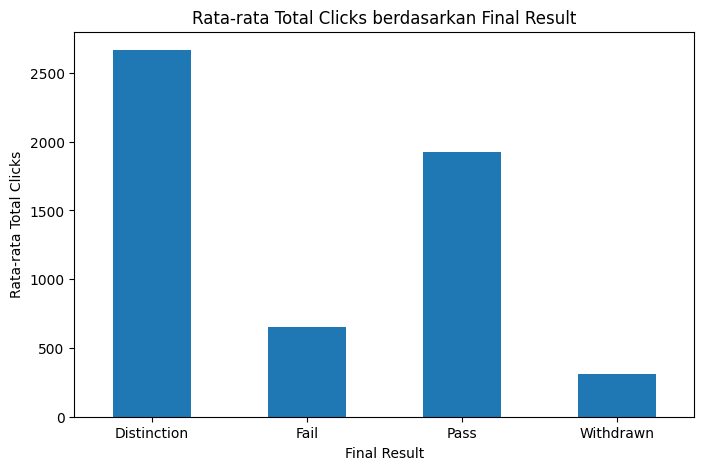

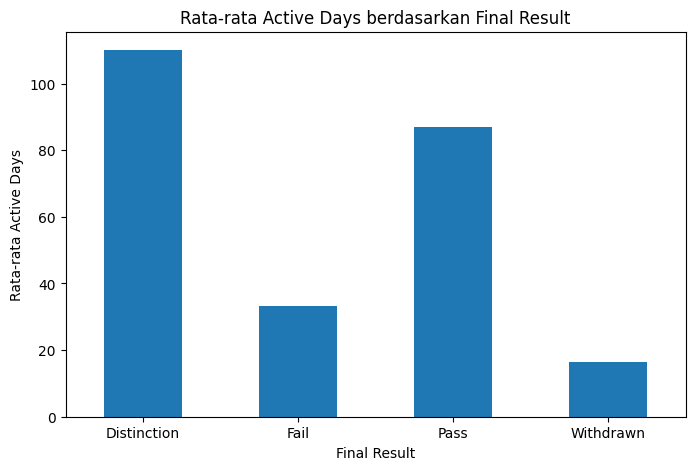

In [6]:
vle_summary = merged_data.groupby("final_result")[
    ["total_clicks", "avg_clicks", "active_days", "last_interaction_day"]
].mean().round(2)

display(vle_summary)

plt.figure(figsize=(8,5))
merged_data.groupby("final_result")["total_clicks"].mean().plot(kind="bar")
plt.title("Rata-rata Total Clicks berdasarkan Final Result")
plt.xlabel("Final Result")
plt.ylabel("Rata-rata Total Clicks")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(8,5))
merged_data.groupby("final_result")["active_days"].mean().plot(kind="bar")
plt.title("Rata-rata Active Days berdasarkan Final Result")
plt.xlabel("Final Result")
plt.ylabel("Rata-rata Active Days")
plt.xticks(rotation=0)
plt.show()

**PERFORMA ASESMEN BERDASARKAN FINAL RESULT**

,avg_score,max_score,assessment_completion_rate
final_result,,,
Distinction,88.49,97.98,1.00
Fail,52.41,64.65,0.79
Pass,76.13,92.29,0.99
Withdrawn,29.41,33.64,0.45


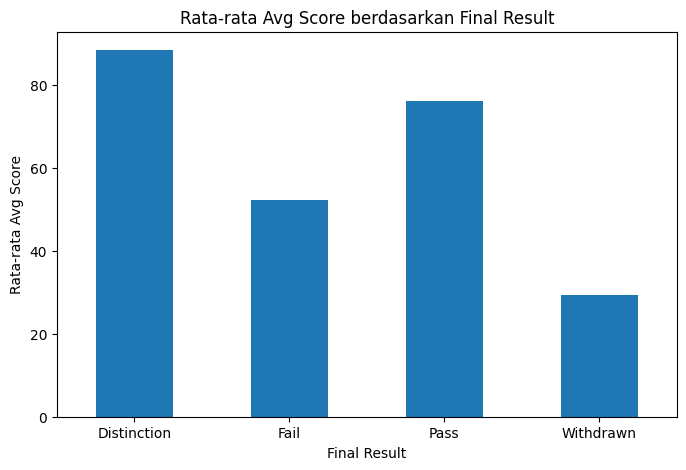

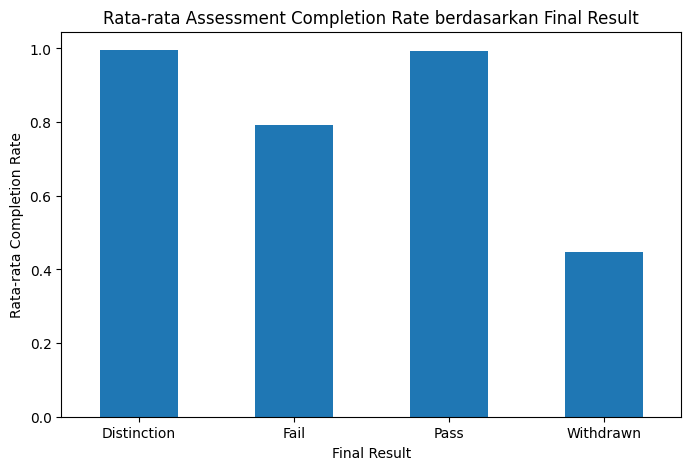

In [7]:
assessment_summary = merged_data.groupby("final_result")[
    ["avg_score", "max_score", "assessment_completion_rate"]
].mean().round(2)

display(assessment_summary)

plt.figure(figsize=(8,5))
merged_data.groupby("final_result")["avg_score"].mean().plot(kind="bar")
plt.title("Rata-rata Avg Score berdasarkan Final Result")
plt.xlabel("Final Result")
plt.ylabel("Rata-rata Avg Score")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(8,5))
merged_data.groupby("final_result")["assessment_completion_rate"].mean().plot(kind="bar")
plt.title("Rata-rata Assessment Completion Rate berdasarkan Final Result")
plt.xlabel("Final Result")
plt.ylabel("Rata-rata Completion Rate")
plt.xticks(rotation=0)
plt.show()

**ANALISIS LOW ENGAGEMENT DAN LOW SCORE**

In [9]:
if "low_engagement" in merged_data.columns:
    low_engagement_result = pd.crosstab(
        merged_data["low_engagement"],
        merged_data["final_result"],
        normalize="index"
    ) * 100

    display(low_engagement_result.round(2))

if "low_score" in merged_data.columns:
    low_score_result = pd.crosstab(
        merged_data["low_score"],
        merged_data["final_result"],
        normalize="index"
    ) * 100

    display(low_score_result.round(2))

final_result,Distinction,Fail,Pass,Withdrawn
low_engagement,,,,
0,16.23,13.97,59.81,9.99
1,2.32,29.31,16.02,52.35


final_result,Distinction,Fail,Pass,Withdrawn
low_score,,,,
0,17.97,13.39,56.05,12.59
1,0.55,29.92,19.74,49.79


**VISUALISASI HASIL MODEL**

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.930357,0.968045,0.897734,0.931565
1,Logistic Regression,0.927136,0.966070,0.893376,0.928302


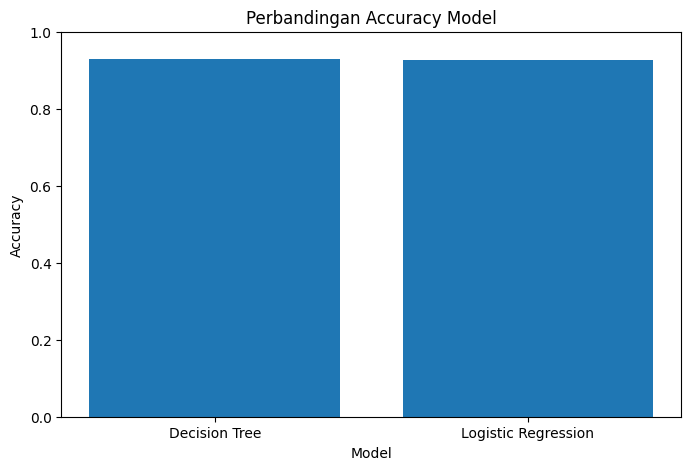

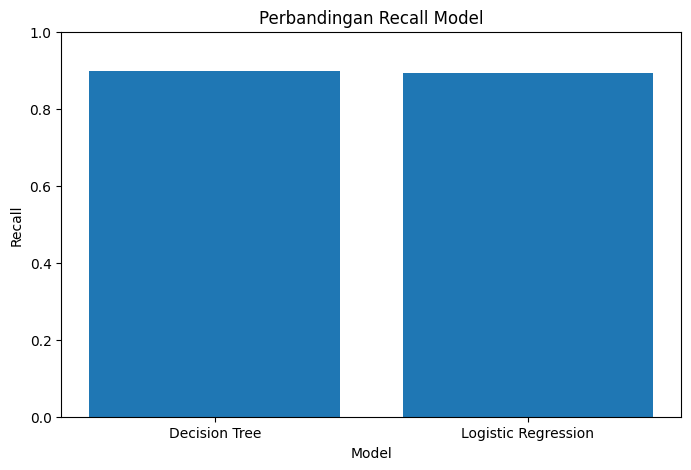

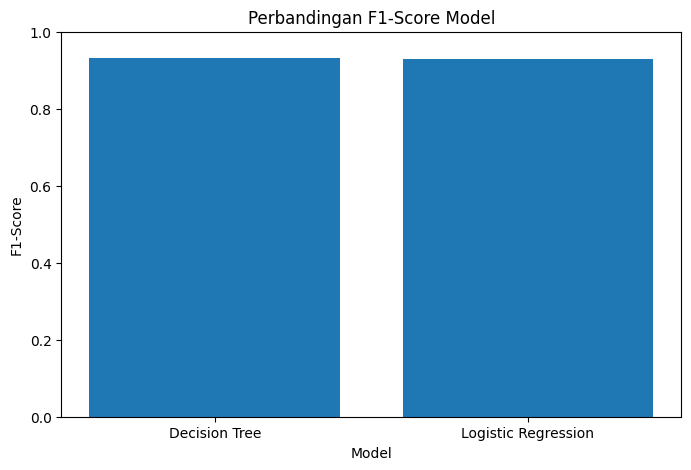

In [10]:
if model_comparison is not None:
    display(model_comparison)

    plt.figure(figsize=(8,5))
    plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
    plt.title("Perbandingan Accuracy Model")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.bar(model_comparison["Model"], model_comparison["Recall"])
    plt.title("Perbandingan Recall Model")
    plt.xlabel("Model")
    plt.ylabel("Recall")
    plt.ylim(0, 1)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.bar(model_comparison["Model"], model_comparison["F1-Score"])
    plt.title("Perbandingan F1-Score Model")
    plt.xlabel("Model")
    plt.ylabel("F1-Score")
    plt.ylim(0, 1)
    plt.show()
else:
    print("model_comparison.csv belum tersedia di folder output.")

**FEATURE IMPORTANCE DECISION TREE**

,feature,importance
0,last_interaction_day,0.887180
1,avg_score,0.070373
2,total_submitted,0.015474
3,total_assessments,0.010920
4,code_module_EEE,0.003585
5,code_module_BBB,0.003380
6,code_module_FFF,0.002661
7,total_clicks,0.002451
8,max_score,0.002421
9,active_days,0.001491


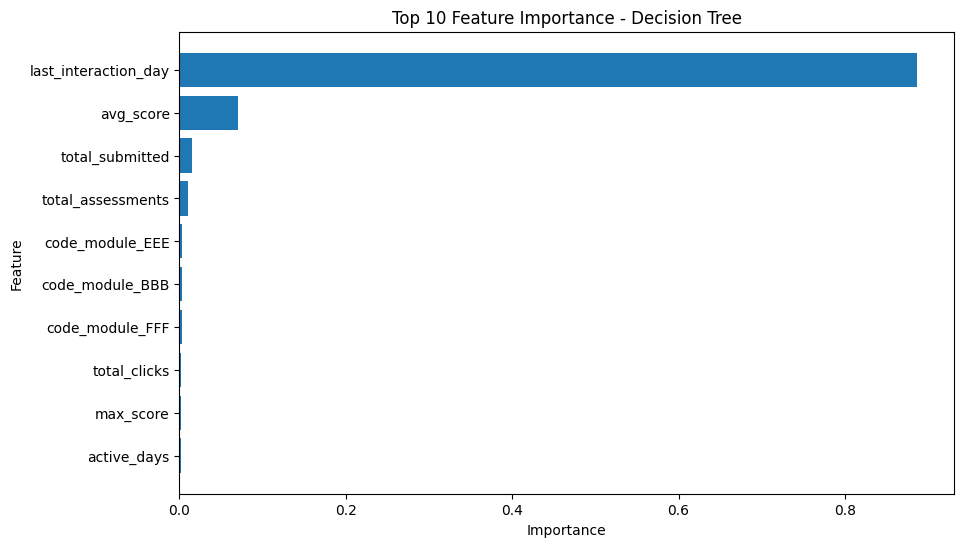

In [11]:
if feature_importance_dt is not None:
    top_features = feature_importance_dt.head(10)
    display(top_features)

    plt.figure(figsize=(10,6))
    plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
    plt.title("Top 10 Feature Importance - Decision Tree")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print("feature_importance_dt.csv belum tersedia di folder output.")

**DAFTAR MAHASISWA BERESIKO**

In [12]:
if at_risk_students is None and "risk_label" in merged_data.columns:
    at_risk_students = merged_data[merged_data["risk_label"] == 1].copy()

if at_risk_students is not None:
    cols_show = [col for col in [
        "id_student", "code_module", "code_presentation",
        "final_result", "risk_label",
        "total_clicks", "avg_score", "assessment_completion_rate"
    ] if col in at_risk_students.columns]

    print("Jumlah mahasiswa berisiko:", len(at_risk_students))
    display(at_risk_students[cols_show].head(20))
else:
    print("Data mahasiswa berisiko belum tersedia.")

Jumlah mahasiswa berisiko: 17208


,id_student,code_module,code_presentation,final_result,risk_label,total_clicks,avg_score,assessment_completion_rate
0,30268,AAA,2013J,Withdrawn,1,281.0,0.00,0.0
1,65002,AAA,2013J,Withdrawn,1,171.0,67.00,1.0
2,74372,AAA,2013J,Fail,1,116.0,48.50,1.0
3,94961,AAA,2013J,Withdrawn,1,339.0,74.00,1.0
4,106247,AAA,2013J,Withdrawn,1,465.0,60.00,1.0
5,129955,AAA,2013J,Withdrawn,1,1011.0,81.00,1.0
6,135335,AAA,2013J,Withdrawn,1,57.0,0.00,0.0
7,135400,AAA,2013J,Withdrawn,1,287.0,61.50,1.0
8,141377,AAA,2013J,Withdrawn,1,143.0,45.00,1.0
9,146188,AAA,2013J,Fail,1,597.0,50.00,1.0


**RINGKASAN DASHBOARD**

In [13]:
print("=== RINGKASAN VISUALISASI ===")
print(f"Total Students                : {total_students}")
print(f"Withdrawal Rate               : {withdrawal_rate:.2f}%")
print(f"Fail Rate                     : {fail_rate:.2f}%")
if engagement_rate is not None:
    print(f"Student Engagement Rate       : {engagement_rate:.2f}%")
if avg_assessment_completion is not None:
    print(f"Assessment Completion Rate    : {avg_assessment_completion:.2f}%")
if at_risk_rate is not None:
    print(f"At-Risk Student Rate          : {at_risk_rate:.2f}%")

=== RINGKASAN VISUALISASI ===
Total Students                : 32593
Withdrawal Rate               : 31.16%
Fail Rate                     : 21.64%
Student Engagement Rate       : 50.03%
Assessment Completion Rate    : 78.00%
At-Risk Student Rate          : 52.80%
